The dataset was obtained from Indian Government [Website](https://www.data.gov.in/resource/crop-survey-gokak-taluk-belagavi-district-karnataka-2020-to2021) which included data of crop survey from Gokak taluk of Belgavi district of Karnataka.

The Data:

1. The dataset contains data on the crop survey of the Gokak Taluk of Belgavi district of Karnataka.
2. There are 114862 entries in the data containing *71* villages and *180* different crops over 12 months.

Objectives of the study:

1. To count total acres of the surveyed area.
2. Identify the most growing crop name and the acres used for it.
2. Identify the most surveyed crop types (kharif or rabi crops)

---
# **Importing libraries and setting themes**
---

In [695]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context='notebook', style='whitegrid') # for notebooks
sns.set_palette('Set1')

---
# **Loading data**
---

In [696]:
path = "../../kaggle_datasets/04_cropsurvey/cropsurvey_gokak.csv" # relative path to the data
df = pd.read_csv(path)
df.drop_duplicates(inplace=True) # Removed 1399 duplicate values

---
# **Data Cleaning**
---

In [697]:
df[[cols for cols in df.columns]].nunique() # To count number of unique values

Survey_id          91371
District_code          1
District_Name          1
Taluk_code             1
Taluk_Name             1
                   ...  
CropSurveyDate        88
Month                 12
Weekname               5
Latitude          107688
Longtitude        108335
Length: 20, dtype: int64

In [698]:
df[['acres', 'cents', 'gunthas']] = df['Crop_Extent'].str.split('[-.]', expand=True).iloc[:,0:3].astype('int16') # split '-' & '.', convert to int and store them as seperate values = acres, cents and gunthas

In [699]:
df.drop(columns=['District_code', 'District_Name', 'Taluk_code', 'Taluk_Name', 'Year_code', 'Years', 'Season_code', 'Season', 'Hobli_code', 'Weekname', 'Crop_Extent'], inplace=True) # Dropping columns with no unique values and no use for analysis

In [700]:
# Changing datatypes for efficient memory usage
df = df.astype({col: 'category' for col in df.select_dtypes('object').columns})
df['Village_code'] = df['Village_code'].astype('int16')

# It reducing memory usage by a whopping 72.8% (from 18.4 MB to just 5.0 MB for 100000+ rows of data!)

In [701]:
df['total_acre'] = df['acres'] + (df['cents'] / 100) + (df['gunthas'] / 40)

---
# **Visualisation**
---

## Objective 1: Total Acres

In [702]:
acres = round(df['acres'].sum() + (df['cents'].sum() / 100) + (df['gunthas'].sum() / 40)) # 100 cents = 1 acre & 40 gunthas = 1 acre
print(f'Total acre of land: {acres} Acres')

Total acre of land: 166452 Acres


## Objective 2: Top Crops with Most Land

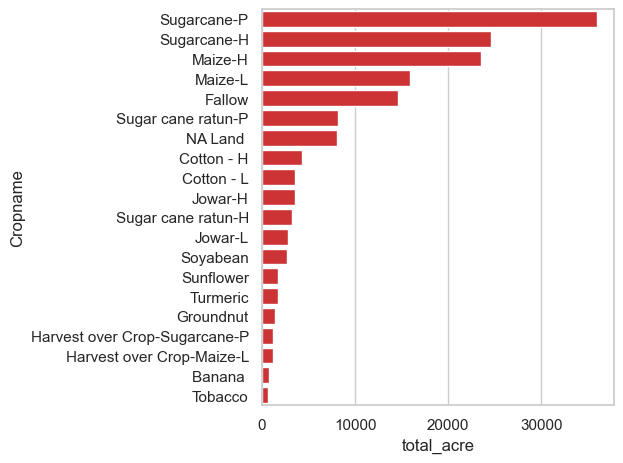

In [703]:
crop_df = df.groupby('Cropname', observed=True)['total_acre'].sum().sort_values(ascending=False).reset_index().head(20) # to get the top 20 crops in the order of land used
sns.barplot(data=crop_df, y='Cropname', x='total_acre', order=crop_df['Cropname'].values)
plt.tight_layout()
plt.savefig('topcrops', dpi=1600)
plt.show()

In [704]:
# To check least grown ones
crop_df_rev = df.groupby('Cropname', observed=True)['total_acre'].sum().sort_values(ascending=True).reset_index().head(10)
crop_df_rev

,Cropname,total_acre
0,Aonla (Amla),0.01
1,Harvest over Crop-Dolichous Bean,0.04
2,Harvest over Crop-Small Millets,0.09
3,Gongura,0.14
4,Subabul,0.17
5,Alocasia,0.20
6,Chive,0.21
7,Harvest over Crop-Green Fodder,0.22
8,Turnip,0.31
9,Curry leaves,0.32


> The most used crop is Sugarcane-P with >35000 acres of occupance in the Gokak taluk.

> The essential crops are:
> 1. Sugarcane
> 2. Maize 

> The least grown ones are:
> 1. Amla
> 2. Harvest over Crop-Dolichous Bean
> 3. Harvest over Crop-Small Millets

## Objective 3: Most Surveyed Crop Types

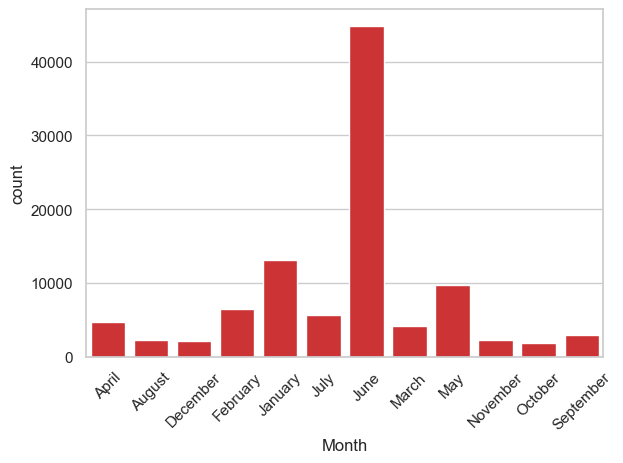

In [707]:
month_df = df.dropna(subset=['Month']).value_counts(['Month']).reset_index() # dropping null values and sorting most occuring values using value_counts()
sns.barplot(data=month_df, x='Month', y='count') # counting which month is the most used for the data
plt.xticks(rotation=45) # rotating xticks
plt.tight_layout()
plt.savefig('mostsurveyedcrop.png', dpi=1600)
plt.show()

> Majority of the crop survey was done in the month of June, mainly indicating kharif crop survey.